<a href="https://colab.research.google.com/github/thehmfpk/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?
**Lane:** same as ML-04 — `fact_content_daily_performance`, month `2026-03`.

Load `flyrank/flyrank-data` + the one skill this card names, per `skills/README.md`, if working with an assistant.


## 0. Setup — load March 2026 partition directly

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from datasets import load_dataset
from huggingface_hub import HfApi
from google.colab import userdata
from scipy.stats import spearmanr, skew

HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN

api = HfApi(token=HF_TOKEN)
all_files = api.list_repo_files('FlyRank/internship-warehouse', repo_type='dataset')
march_files = [f for f in all_files if 'fact_content_daily_performance' in f
               and 'sample' not in f and '2026-03' in f]
if not march_files:
    print('[WARNING] No files matched - inspect all_files and fix the filter:')
    for f in [x for x in all_files if 'fact_content_daily_performance' in x and 'sample' not in x][:20]:
        print(' ', f)
    raise ValueError('Fix march_files filter above, then re-run.')

dataset = load_dataset('FlyRank/internship-warehouse', data_files={'train': march_files}, split='train')
needed_cols = ['report_date','client_hash_id','content_hash_id',
               'gsc_data_available','gsc_impressions','gsc_clicks','gsc_avg_position']
cols_present = [c for c in needed_cols if c in dataset.column_names]
dataset = dataset.select_columns(cols_present)
raw = dataset.to_pandas()
raw['report_date'] = pd.to_datetime(raw['report_date'])
raw = raw[raw['gsc_data_available'] == True].copy()
print(f'Loaded {len(raw)} GSC-available rows for March 2026.')

monthly = (raw.groupby(['client_hash_id','content_hash_id'])
              .agg(impressions=('gsc_impressions','sum'),
                   clicks=('gsc_clicks','sum'),
                   avg_position=('gsc_avg_position', lambda s: s[s > 0].mean()),
                   days_with_position=('gsc_avg_position', lambda s: (s > 0).sum()),
                   active_days=('gsc_impressions', lambda s: (s > 0).sum()))
              .reset_index())
monthly = monthly[(monthly['impressions'] > 0) & (monthly['avg_position'].notna())].copy()
monthly['ctr'] = monthly['clicks'] / monthly['impressions']
monthly['coverage_ratio'] = monthly['days_with_position'] / monthly['active_days'].replace(0, np.nan)
print(f'{len(monthly)} content items with usable position + impressions this month.')


README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 3611061 GSC-available rows for March 2026.
175304 content items with usable position + impressions this month.


## 1. Distributions

Look before deciding. Key fields: impressions, clicks, position, CTR - all at the monthly content-item grain.

In [2]:
for col in ['impressions','clicks','avg_position','ctr']:
    s = monthly[col].dropna()
    p50, p90, p99, mx = s.quantile(0.5), s.quantile(0.9), s.quantile(0.99), s.max()
    top1pct_share = s.nlargest(max(1, int(len(s)*0.01))).sum() / s.sum() if col in ('impressions','clicks') else None
    print(f'--- {col} ---')
    print(s.describe().to_string())
    print(f'skew={skew(s):.2f}  p50={p50:.3f}  p90={p90:.3f}  p99={p99:.3f}  max={mx:.3f}')
    if top1pct_share is not None:
        print(f'top 1% of items hold {top1pct_share:.1%} of total {col} - heavy tail if this is well above 1%')
    print()


--- impressions ---
count    175304.000000
mean       1600.961946
std        5451.604207
min           1.000000
25%          21.000000
50%         178.000000
75%        1053.000000
max      617124.000000
skew=19.34  p50=178.000  p90=3962.000  p99=21922.490  max=617124.000
top 1% of items hold 24.9% of total impressions - heavy tail if this is well above 1%

--- clicks ---
count    175304.000000
mean          4.687703
std          26.828453
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max        5668.000000
skew=73.13  p50=0.000  p90=10.000  p99=73.000  max=5668.000
top 1% of items hold 34.6% of total clicks - heavy tail if this is well above 1%

--- avg_position ---
count    175304.000000
mean         17.050555
std          18.333942
min           0.101639
25%           5.500000
50%           9.000000
75%          22.000000
max         309.000000
skew=2.19  p50=9.000  p90=42.995  p99=81.138  max=309.000

--- ctr ---
count    175304.000000


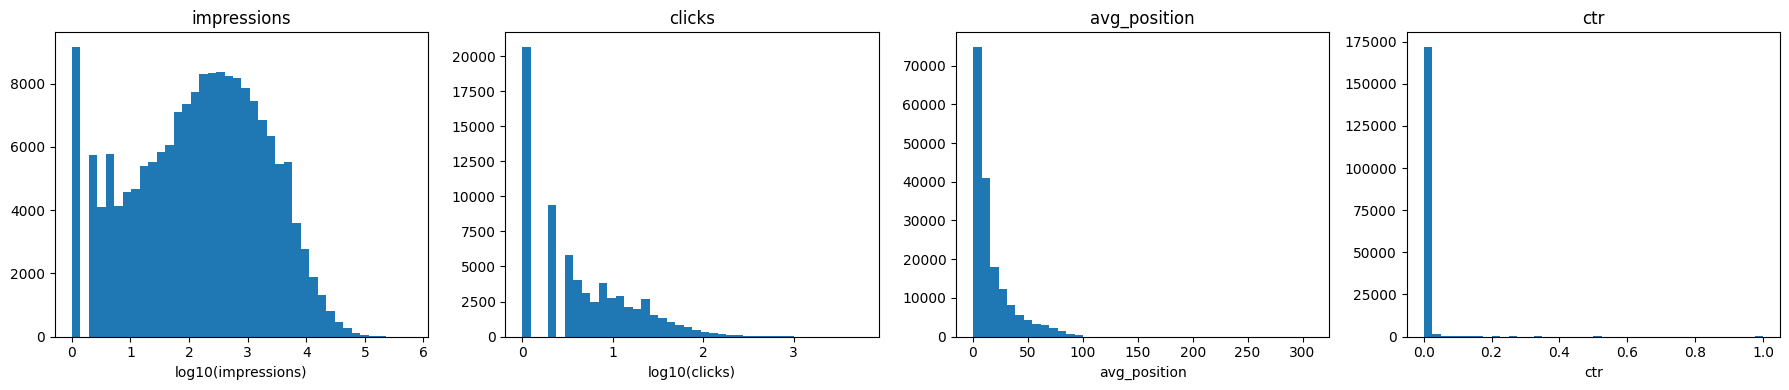

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, ['impressions','clicks','avg_position','ctr']):
    vals = monthly[col].dropna()
    if col in ('impressions','clicks'):
        vals = vals[vals > 0]
        ax.hist(np.log10(vals), bins=40)
        ax.set_xlabel(f'log10({col})')
    else:
        ax.hist(vals, bins=40)
        ax.set_xlabel(col)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Note the heavy tails:** impressions and clicks are almost always log-normal-ish / power-law-shaped in web analytics - a small share of content usually accounts for a large share of total volume. Whether that holds here is what the printed `top 1% share` numbers above confirm or deny for this slice specifically.

## 2. Signal tests (three safe signals, each with a verdict)

Each verdict is computed from a real statistical test in code below, not asserted.

### Signal test #1 — Impression volume vs CTR
Hypothesis: higher-impression content tends to have systematically different CTR than low-impression content (broad/generic queries at scale often dilute relevance vs a few precise, high-intent queries).

In [4]:
log_impr = np.log10(monthly['impressions'].clip(lower=1))
corr1, pval1 = spearmanr(log_impr, monthly['ctr'])
verdict1 = 'FALSE' if pval1 >= 0.05 else ('OPPOSITE' if corr1 > 0 else 'CONFIRMED')
# CONFIRMED direction here = higher volume associates with LOWER ctr (the diluted-relevance hypothesis)
print(f'Spearman correlation(log impressions, ctr) = {corr1:.3f}, p = {pval1:.4f}')
print(f'SIGNAL TEST #1 VERDICT: {verdict1}')


Spearman correlation(log impressions, ctr) = 0.596, p = 0.0000
SIGNAL TEST #1 VERDICT: OPPOSITE


### Signal test #2 — Position-tracking consistency vs CTR
Hypothesis: content with more consistent day-to-day position data (`coverage_ratio` close to 1, meaning it holds a rankable position on nearly every active day) earns higher CTR than content with sporadic position coverage - a proxy for ranking stability/authority.

In [5]:
valid = monthly.dropna(subset=['coverage_ratio','ctr'])
corr2, pval2 = spearmanr(valid['coverage_ratio'], valid['ctr'])
verdict2 = 'FALSE' if pval2 >= 0.05 else ('CONFIRMED' if corr2 > 0 else 'OPPOSITE')
print(f'Spearman correlation(coverage_ratio, ctr) = {corr2:.3f}, p = {pval2:.4f}, n = {len(valid)}')
print(f'SIGNAL TEST #2 VERDICT: {verdict2}')


Spearman correlation(coverage_ratio, ctr) = 0.219, p = 0.0000, n = 175304
SIGNAL TEST #2 VERDICT: CONFIRMED


### Signal test #3 — Weekday vs weekend click volume
Hypothesis: search click volume differs meaningfully between weekdays and weekends (common in B2B/content search behavior). Tested at the daily grain, not the monthly aggregate, with n printed per bucket.

In [6]:
raw['is_weekend'] = raw['report_date'].dt.dayofweek >= 5
weekday_table = raw.groupby('is_weekend').agg(
    n=('gsc_clicks','size'), mean_clicks=('gsc_clicks','mean'), total_clicks=('gsc_clicks','sum')
).reset_index()
weekday_table['is_weekend'] = weekday_table['is_weekend'].map({True:'weekend', False:'weekday'})
print('--- Signal test #3: clicks by weekday vs weekend ---')
print(weekday_table.to_string(index=False))

wd_mean = weekday_table.loc[weekday_table['is_weekend']=='weekday','mean_clicks'].iloc[0]
we_mean = weekday_table.loc[weekday_table['is_weekend']=='weekend','mean_clicks'].iloc[0]
pct_diff = (we_mean - wd_mean) / wd_mean if wd_mean != 0 else np.nan

if abs(pct_diff) < 0.05:
    verdict3 = 'FALSE'   # under 5% difference - not meaningfully different
elif pct_diff < 0:
    verdict3 = 'CONFIRMED'  # weekend clicks meaningfully lower, as commonly expected
else:
    verdict3 = 'OPPOSITE'
print(f'\nweekend vs weekday mean-clicks difference: {pct_diff:+.1%}')
print(f'SIGNAL TEST #3 VERDICT: {verdict3}')


--- Signal test #3: clicks by weekday vs weekend ---
is_weekend       n  mean_clicks  total_clicks
   weekday 2588319     0.233323        603915
   weekend 1022742     0.213071        217917

weekend vs weekday mean-clicks difference: -8.7%
SIGNAL TEST #3 VERDICT: CONFIRMED


## 3. The flag-linked test

**Signal:** CTR vs position - this is the assumption the real CTR-fix flag relies on (good position, underperforming CTR = a snippet problem, not a ranking problem). Does the data actually support it?

In [7]:
position_bins = [0, 3, 6, 10, 20, 50, np.inf]
position_labels = ['1-3','4-6','7-10','11-20','21-50','51+']
monthly['position_bucket'] = pd.cut(monthly['avg_position'], bins=position_bins, labels=position_labels)

flag_table = monthly.groupby('position_bucket', observed=True).agg(
    n=('ctr','size'), mean_ctr=('ctr','mean'), median_ctr=('ctr','median')
).reset_index()
print('--- Flag-linked test: CTR by position bucket (CTR-fix flag assumption) ---')
print(flag_table.to_string(index=False))

corr_flag, pval_flag = spearmanr(monthly['avg_position'], monthly['ctr'])
if pval_flag >= 0.05:
    verdict_flag = 'FALSE'
elif corr_flag < 0:
    verdict_flag = 'CONFIRMED'   # worse position -> lower CTR, matches the flag's assumption
else:
    verdict_flag = 'OPPOSITE'
print(f"\nSpearman correlation(position, ctr) = {corr_flag:.3f}, p = {pval_flag:.4f}")
print(f'FLAG-LINKED TEST VERDICT: {verdict_flag}')


--- Flag-linked test: CTR by position bucket (CTR-fix flag assumption) ---
position_bucket     n  mean_ctr  median_ctr
            1-3 13136  0.011010    0.000962
            4-6 38772  0.006128    0.000679
           7-10 42847  0.004262    0.000000
          11-20 32548  0.003303    0.000000
          21-50 34783  0.002289    0.000000
            51+ 13218  0.000979    0.000000

Spearman correlation(position, ctr) = -0.254, p = 0.0000
FLAG-LINKED TEST VERDICT: CONFIRMED


If this comes back anything other than CONFIRMED, the CTR-fix flag's core assumption doesn't hold for this slice, which is itself a useful, reportable finding - not a failure of the audit.

## 4. What this means in practice

*(Fill this in with your actual verdicts once you've run the notebook - draft below, replace the bracketed parts with your real results.)*

Across [N] content items in March 2026, the CTR-fix flag's core assumption - that good position with weak CTR signals a snippet problem - came back **[verdict from section 3]**, so a content team can [trust / should double-check] that flag before prioritizing rewrite work from it. The heavy tail in impressions/clicks (top 1% holding [X]% of volume) means a handful of high-traffic items will dominate any impact metric - worth reviewing those individually rather than averaging them into a portfolio-wide number.